# E-commerce Sales Analysis

## Business Context

E-commerce platforms generate large volumes of transactional data on a daily basis. Understanding this data is essential for improving business performance, optimizing product offerings, and enhancing customer experience.

In this project, we analyze histrical sales data from an online retail business to uncover patternsin sales, customer behavior, and product performance.

## Objective

The main objectives of this analysis are:
- Analyze overall sales trends over time
- Identify top-performing and underperforming products
- Explore customer purchasing behavior
- Examine sales distribution across different countries
- Generate actionable business insights

## Dataset

This dataset consists of transactional data from an online retail business, capturing customer purchases, product information, pricing, and temoral sales patterns.

## Data Inspection

**Goal:**
Understand the structure of the dataset.

**Steps:**
- Load dataset into pandas DataFrame
- Inspect first rows
- Check column types and missing values
- Generate summary statistics

In [2]:
# Import library pandas
import pandas as pd

In [3]:
# Install openpyxl in the current kernel enviroment
import sys #引入python系统模块(System)
!{sys.executable} -m pip install openpyxl #{sys.executable}把python路径插入到命令里,-m用python运行一个模块,pip是python的管理工具(App store)


[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip


In [4]:
import os #引入操作系统模块(Operating System),以接触电脑文件系统

#os.getcwd() = get curent working directory返回当前工作目录，即当前所在位置
os.listdir("../data") #os.listdir()列出当前目录下所有文件和文件夹, os.listdir("../data")查看上一级data文件夹, .DS_Store是系统隐藏文件, ..上一级, ../..上两级

['.DS_Store', 'online_retail_II.xlsx']

In [5]:
#查看.gitignore是否在30Day-Reboot文件里
os.getcwd()#我在哪儿
os.listdir("../..")

['.Rhistory',
 'ecommerce_sales_analysis',
 'restaurant_tips_analysis',
 '.gitignore',
 '.ipynb_checkpoints',
 'Git命令拆解.pages',
 '.git']

In [39]:
#在Notebook创建/更新根目录下黑名单(.gitignore)

import os
#根目录路径(Notebook在ecommerce_sales_analysis/notebook)
gitignore_path = "../../.gitignore"

#内容
gitignore_content = """ 
# macOS
.DS_Store #系统文件

# Python
__pycache__/ #python缓存
*.pyc

#Jupyter
.ipynb_checkpoints/ #Jupyter检查点

#R
.Rhistory

# Logs
*.log #日志

# VS Code settings
.vscode/ #编辑器

.pages

""" #"""为python多行字符串

# 写入文件
with open(gitignore_path, "w") as f: #w模式=若已存在.gitignore就覆盖, f=文件对象(打开的文件)
    f.write(gitignore_content.strip()) #strip()去掉首尾空行

print(".gitignore 已经创建/更新在:", gitignore_path)

# 追加文件内容

with open(gitignore_path, "r") as f: #r=读取
    content = f.read() #f.read()把文件全部读出来

if "*.log" not in content:
    with open(gitignore_path, "a") as f: #a模式=append在末尾追加
        f.write("\n*.log.strip()\n") #\n自动换行

print("Content appended to .gitignore")

os.listdir("../") #检查黑名单是否出现在根目录

.gitignore 已经创建/更新在: ../../.gitignore
Content appended to .gitignore


['README.md', 'notebook', 'data']

In [6]:
gitignore_path = "../../.gitignore"

new_content = """
.DS_Store
__pycache__/
*.pyc
.ipynb_checkpoints/
.vscode/
"""

with open(gitignore_path, "r") as f:
    content = f.read()

if new_content.strip() not in content:
    with open(gitignore_path, "a") as f:
        f.write("\n" + new_content.strip() + "\n")

print("New content appended to .gitignore")

New content appended to .gitignore


In [7]:
# Load dataset
df = pd.read_excel("../data/online_retail_II.xlsx", sheet_name="Year 2010-2011")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[ns]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [9]:
df.describe

<bound method NDFrame.describe of        Invoice StockCode                          Description  Quantity  \
0       536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1       536365     71053                  WHITE METAL LANTERN         6   
2       536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3       536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4       536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...        ...       ...                                  ...       ...   
541905  581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906  581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907  581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908  581587     22138        BAKING SET 9 PIECE RETROSPOT          3   
541909  581587      POST                              POSTAGE         1   

               InvoiceDate  Price  Customer ID         Country  


In [10]:
## Data Cleaning

#Check out negative numbers (Refund)
(df["Quantity"] < 0).sum()

np.int64(10624)

In [11]:
df[df["Quantity"] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [12]:
#Save positive data as sales and negative data as returns
df_sales = df[df["Quantity"] > 0].copy() #copy.()创建独立数据副本，避免“连带修改”
df_returns = df[df["Quantity"] < 0].copy()

In [13]:
df_sales.shape

(531286, 8)

In [14]:
sum = 531286+10624
print(sum)

541910


There are 10624 rows of nagative quantities which invoice IDs begin with "C". This indicates product returns or cancellations, so I excluded them to focus on actual sales transactions. I preserved the original dataset and created separate subsets for sales and returns to enable flexible analysis.

In [15]:
# Check missing values in column "Customer ID"
df_sales["Customer ID"].isnull().sum()

np.int64(133361)

In [16]:
# Remove the missing value from column "Customer ID"
df_sales = df_sales.dropna(subset=["Customer ID"]).copy() #subset为dropna参数，只检查指定列是否有缺失值

#Customer ID数据类型为float64（有小数点），因为这一列有缺失值不能存int，被pandas自动转换

df_sales["Customer ID"] = df_sales["Customer ID"].astype(int).astype(str) #将数据类型从float改为不含小数点的(int)字符串(str)
df_sales["Customer ID"].dtype #返回结果dtype('O')，O=Object=字符串

dtype('O')

In [17]:
df_sales["Customer ID"].isnull().sum()

np.int64(0)

133361 missing values were in the column "Customer ID". I removed these records to ensure the dataset is suitable for customer-level analysis.

In [18]:
# Convert InvoiceDate from string to datetime for time-based analysis
df_sales["InvoiceDate"] = pd.to_datetime(df_sales["InvoiceDate"]) #pd.to_datetime()将时间字符串转换成时间格式

In [19]:
## Monthly Sales Trend

#df_sales["YearMonth"] = df_sales["InvoiceDate"].dt.to_period("M") #dt.为pandas时间处理工具，to_period("M")把时间转换成按月的时间单位且同月份不同年也会被正确分组
#monthly_sales = df_sales.groupby("YearMonth")["TotalPrice"].sum() #groupby("YeearMonth")数据按月份分组，其中"TotalPrice"这一列在每个分组内求和

# Create sales
df_sales["TotalPrice"] = df_sales["Quantity"] * df_sales["Price"]

monthly_sales = df_sales.resample("ME", on="InvoiceDate")["TotalPrice"].sum()
monthly_sales.head()

InvoiceDate
2010-12-31    572713.890
2011-01-31    569445.040
2011-02-28    447137.350
2011-03-31    595500.760
2011-04-30    469200.361
Freq: ME, Name: TotalPrice, dtype: float64

In [20]:
## Visualization

# Import library seaborn
import seaborn as sns
import matplotlib.pyplot as plt

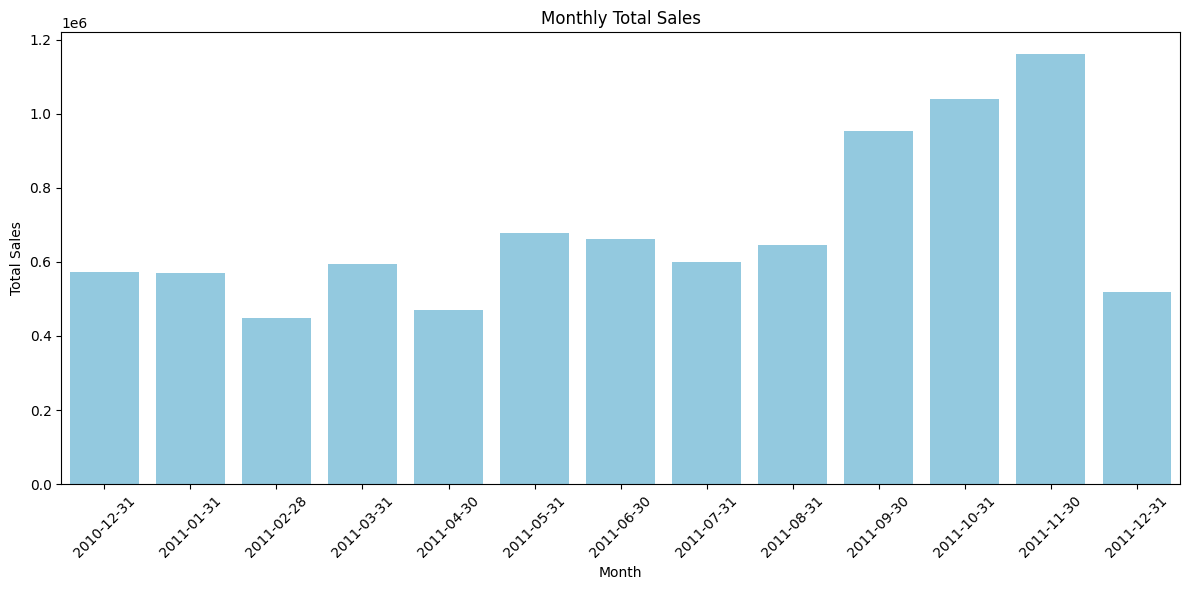

In [21]:
#Barplot InvoiceDate vs TotalPrice
monthly_sales_df = monthly_sales.reset_index() #把索引变成列

plt.figure(figsize=(12, 6))
sns.barplot(x="InvoiceDate", y="TotalPrice", data=monthly_sales_df, color="skyblue")
plt.xticks(rotation=45)
plt.title("Monthly Total Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.tight_layout()
#plt.show()

#plt.savefig("monthly_sales.png")
#print("图表已保存为 monthly_sales.png")

### Observations:
Monthly sales show noticeable fluctuations over time, with a general upward trend and several peaks, suggesting seasonality and varying customer demand across months. Sales appear to increase toward the end of the year, indicating potential holiday-driven demand.

In [22]:
# Check extreme values
monthly_sales_max = monthly_sales.idxmax(), monthly_sales.max().round(2) #idxmax()为最大值出现的位置，.max()为最大值的数值，.round()保留小数点后几位
print(monthly_sales_max)

monthly_sales_min = monthly_sales.idxmin(), monthly_sales.min()
print(monthly_sales_min)

(Timestamp('2011-11-30 00:00:00'), np.float64(1161817.38))
(Timestamp('2011-02-28 00:00:00'), np.float64(447137.35))


### Observations:
Monthly sales show clear fluctuations throughout the year. The highest sales occurred in **November 2011**, reaching approximately **1.16 million**, while the lowest sales were recorded in **February 2011**, at around **447 thousand**. This significant variation suggests strong seasonality in customer demand, with sales peaking toward the end of the year and droppping in early months. 

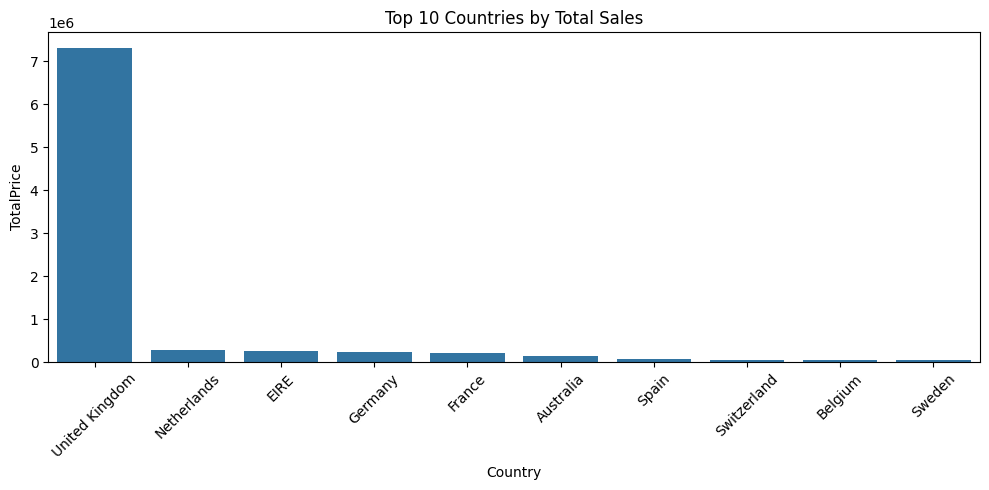

In [ ]:
# Top countries analysis
top_countries = df_sales.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)
top_countries_df = top_countries.reset_index()

# Visual
plt.figure(figsize=(10, 5))
sns.barplot(x="Country", y="TotalPrice", data=top_countries_df)
plt.xticks(rotation=45) #把X轴的刻度标签旋转45度
plt.title("Top 10 Countries by Total Sales")
plt.tight_layout() #自动调整边距

#plt.savefig("top_countries.png")

### Observations

The United Kingdom overwhelmingly leads in total sales, far exceeding all other countrieds. This suggests that the business is neavily dependent on a single market. While countries like the Netherlands, ireland, Germany, and France contribute to revenue, their impact is relatively small in comparison. This coucentration indicates potential risk, as performance is highly tied to one geographic region. This also suggests an opportunity to expand into other international markets to diversify revenue streams.

In [24]:
# Customer Analysis

# Top Customer
top_customers = df_sales.groupby("Customer ID")["TotalPrice"].sum().sort_values(ascending=False).head(10)
top_customers

Customer ID
14646    280206.02
18102    259657.30
17450    194550.79
16446    168472.50
14911    143825.06
12415    124914.53
14156    117379.63
17511     91062.38
16029     81024.84
12346     77183.60
Name: TotalPrice, dtype: float64

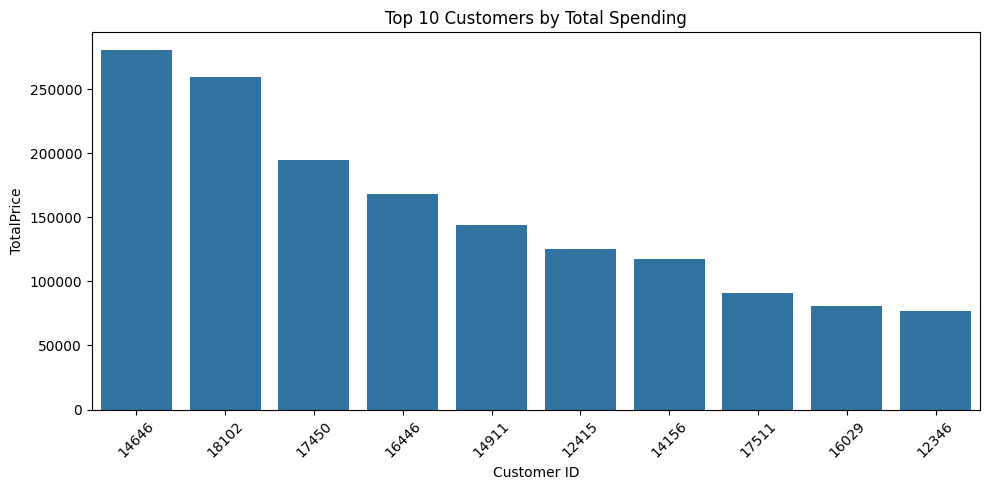

In [25]:
top_customers_df = top_customers.reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x="Customer ID", y="TotalPrice", data=top_customers_df)
plt.xticks(rotation=45)
plt.title("Top 10 Customers by Total Spending")
plt.tight_layout()

#plt.savefig("top_customers.png")

The top customers contribute significantly more revenue than the rest, with the highest-spending customer exceeding 280,000 in total purchases. This indicates a strong concentration of revenue among a small group of hight-value customers. Such a pattern suggests that the business relies heavily on a limited number of key customers. It also suggests an opportunity to design targeted marketing strategies for high-value customers to maximize lifetime value.

In [26]:
# Customer Segmentation

# RFM Analysis (Recency, Frequency, Monetary)
rfm = df_sales.groupby("Customer ID").agg({
    "InvoiceDate": "max",
    "Invoice": "nunique",
    "TotalPrice": "sum"
})

rfm.columns = ["LastPurchase", "Frequency", "Monetary"]
rfm.head()

,LastPurchase,Frequency,Monetary
Customer ID,,,
12346,2011-01-18 10:01:00,1,77183.60
12347,2011-12-07 15:52:00,7,4310.00
12348,2011-09-25 13:13:00,4,1797.24
12349,2011-11-21 09:51:00,1,1757.55
12350,2011-02-02 16:01:00,1,334.40


In [27]:
snapshot_date = df_sales["InvoiceDate"].max() + pd.Timedelta(days=1) #define "today", data[““].max()从数据列中找出最大值，此处即最后一次交易具体时间，pd.Timedelta(days=1)创建时长为1天的时间差，+1是为了避免出现“刚买=0天”

# Recency
rfm["Recency"] = (snapshot_date - rfm["LastPurchase"]).dt.days
rfm.head()

,LastPurchase,Frequency,Monetary,Recency
Customer ID,,,,
12346,2011-01-18 10:01:00,1,77183.60,326
12347,2011-12-07 15:52:00,7,4310.00,2
12348,2011-09-25 13:13:00,4,1797.24,75
12349,2011-11-21 09:51:00,1,1757.55,19
12350,2011-02-02 16:01:00,1,334.40,310


In [28]:
# RFM Distribution

rfm.describe()

,LastPurchase,Frequency,Monetary,Recency
count,4339,4339.000000,4339.000000,4339.000000
mean,2011-09-08 12:04:55.782438400,4.271952,2053.797166,92.518322
min,2010-12-01 09:53:00,1.000000,0.000000,1.000000
25%,2011-07-21 00:20:00,1.000000,307.245000,18.000000
50%,2011-10-20 10:47:00,2.000000,674.450000,51.000000
75%,2011-11-22 11:10:30,5.000000,1661.640000,142.000000
max,2011-12-09 12:50:00,210.000000,280206.020000,374.000000
std,NaN,7.705493,8988.247836,100.009747


### Insight
The summary statistics reveal a highly uneven customer distribution. The majority of customers purchase infrequently and spend relatively little, while a small proportion of customers exhibit high purchase frequency and significantly higher monetary value. Additionally, the wide range in recency suggests that many customers habe not engaged recently, indicating potential churn risk. These patterns justify the need for customer segmentation using RFM analysis.

In [29]:
# RFM Scoring

# Recency Scoring
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1]) #越小越好

In [30]:
# Frequency Scoring
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]) #越大越好

In [31]:
# Monetary Scoring
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5]) #越大越好

rfm.head()

,LastPurchase,Frequency,Monetary,Recency,R_score,F_score,M_score
Customer ID,,,,,,,
12346,2011-01-18 10:01:00,1,77183.60,326,1,1,5
12347,2011-12-07 15:52:00,7,4310.00,2,5,5,5
12348,2011-09-25 13:13:00,4,1797.24,75,2,4,4
12349,2011-11-21 09:51:00,1,1757.55,19,4,1,4
12350,2011-02-02 16:01:00,1,334.40,310,1,1,2


In [32]:
rfm["RFM_Score"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)
rfm.head()

,LastPurchase,Frequency,Monetary,Recency,R_score,F_score,M_score,RFM_Score
Customer ID,,,,,,,,
12346,2011-01-18 10:01:00,1,77183.60,326,1,1,5,115
12347,2011-12-07 15:52:00,7,4310.00,2,5,5,5,555
12348,2011-09-25 13:13:00,4,1797.24,75,2,4,4,244
12349,2011-11-21 09:51:00,1,1757.55,19,4,1,4,414
12350,2011-02-02 16:01:00,1,334.40,310,1,1,2,112


In [ ]:
# Customer Segmentation

def segment(row):
    if row["RFM_Score"] == "555":
        return "VIP"
    elif row["R_score"] >= 4 and row["F_score"] >= 4:
        return "Loyal"
    elif row["R_score"] >= 4:
        return "Recent"
    elif row["R_score"] <= 2:
        return "At Risk"
    else:
        return "Others"
rfm["Segment"] = rfm.apply(segment, axis=1)

rfm["Segment"].value_counts() #统计每个分类中有多少个客户

Segment
At Risk    1708
Others      858
Loyal       791
Recent      634
VIP         348
Name: count, dtype: int64

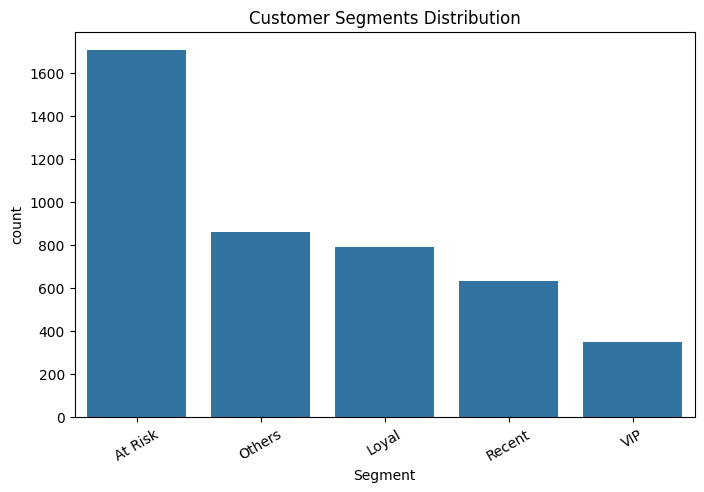

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x="Segment", data=rfm, order=rfm["Segment"].value_counts().index) #order决定柱状图中分类的显示顺序，rfm["Segment"].value_counts()为统计每个分类中有多少个客户且由多到少排列顺序，.index取分类标签
plt.title("Customer Segments Distribution")
plt.xticks(rotation=30)

plt.show()

### Observation

The RFM analysis highlights a highly segmented customer base. A small group of high-value customers (VIPs) countributes significantly to total revenue, confirming the presence of a Pareto-like distribution. Meanwhile, a large number of customers exhibit low recency scores, indicating potential churn risk. This imbalance suggests that the business should prioritize retention of high-value customers while re-engaging at risk customers through targeted marketing strategies.

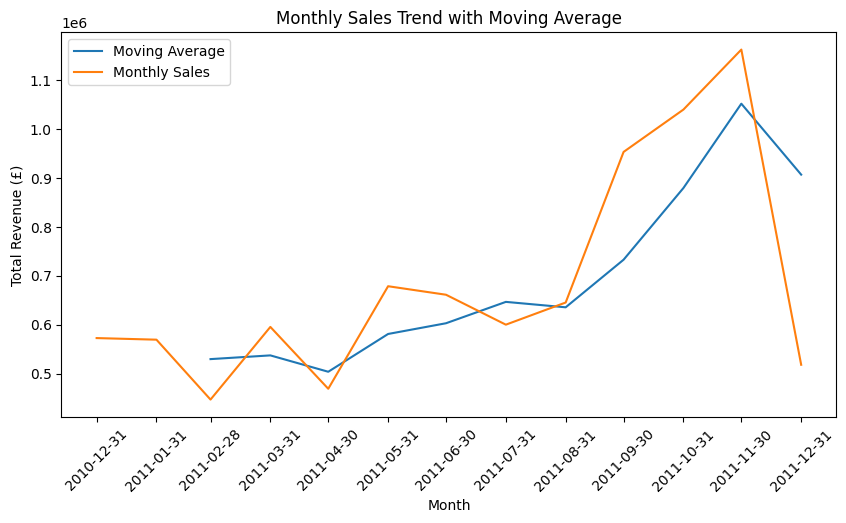

In [ ]:
# Moving Average

monthly_sales_MA = monthly_sales.rolling(3).mean() #rolling(3)从存在三个数据开始做平均值，以便用完整窗口做平滑使统计数据稳定

plt.figure(figsize=(10, 5))
plt.title("Monthly Sales Trend with Moving Average")
plt.xlabel("Month")
plt.ylabel("Total Revenue (£)")
plt.plot(monthly_sales_MA, label="Moving Average")
plt.plot(monthly_sales, label="Monthly Sales")
plt.legend()
plt.xticks(monthly_sales.index, rotation=45) #monthly_sales.index为强制显示全部时间点
plt.show()

### Observation

The monthly sales trend shows a clear upward trajectory throughout most of the year, indicating overall business growth. The moving average line smooths short-term fluctuations and confirms a consistent increasing trend, particularly from mid-year onward.

A significant spike is observed in the final months, likely driven by seasonal effects such as holiday shopping. However, a sharp drop at the beginning of the follwing period suggests either incomplete data for that month or a post-holiday decline in demand.

Overall, the pattern indicates strong seasonality and highlights the importance of peak periods in driving annual revenue.

In [43]:
# Monthly Growth Rate

monthly_growth = monthly_sales.pct_change() #pct_change()为当前月vs上个月的增长率

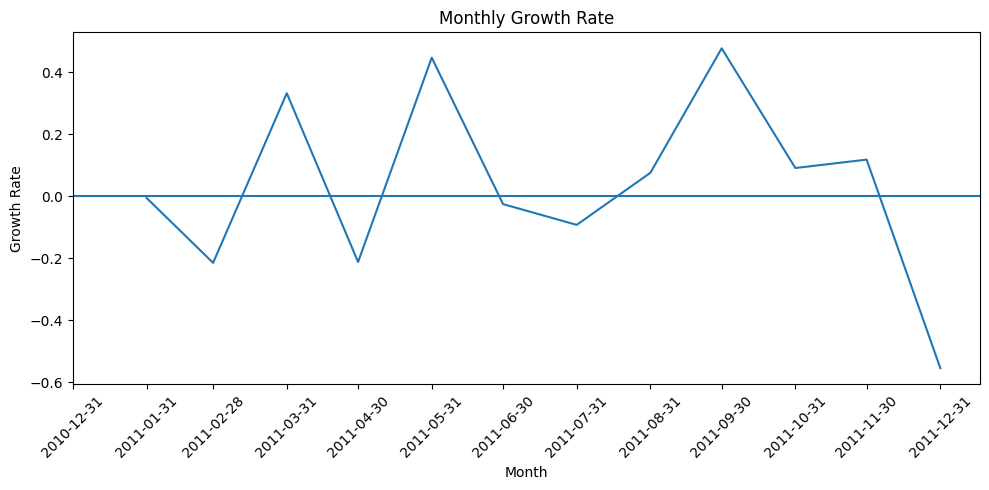

In [49]:
# Visual

plt.figure(figsize=(10,5))
plt.plot(monthly_growth.index, monthly_growth.values)
plt.title("Monthly Growth Rate")
plt.xlabel("Month")
plt.ylabel("Growth Rate")
plt.axhline(0) #0线
plt.xticks(monthly_growth.index, rotation=45) #monthly_growth.index为强制显示全部时间点
plt.tight_layout()
plt.show()

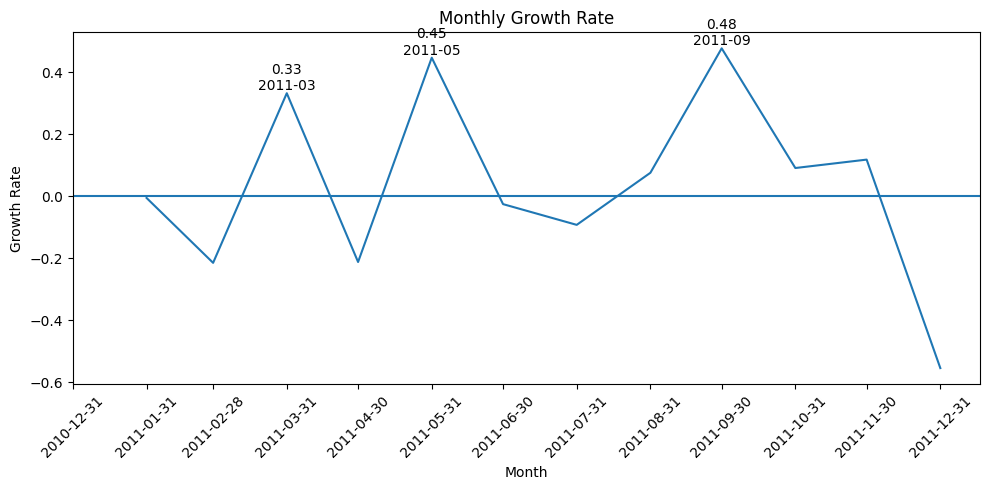

In [ ]:
# Visual

plt.figure(figsize=(10,5))
plt.plot(monthly_growth.index, monthly_growth.values)
plt.title("Monthly Growth Rate")
plt.xlabel("Month")
plt.ylabel("Growth Rate")
plt.axhline(0) #0线

#Find top3 peek value
top_growth = monthly_growth.nlargest(3) 
for date, value in top_growth.items():
    plt.text(
        date,
        value,
        f"{value:.2f}\n{date.strftime('%Y-%m')}",
        ha='center',
        va='bottom'
    )

plt.xticks(monthly_growth.index, rotation=45) #monthly_growth.index为强制显示全部时间点
plt.tight_layout()
plt.show()

(-0.753965365882201, 0.6764815813708007)

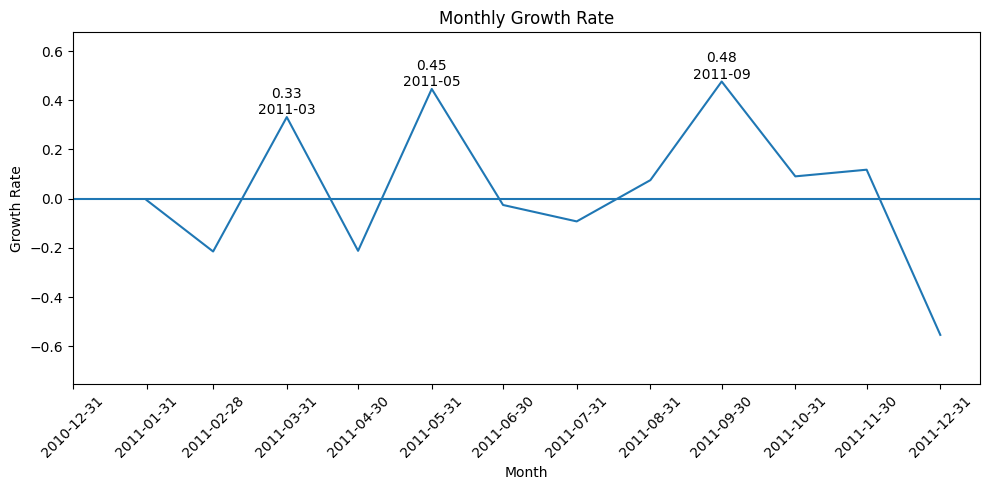

In [ ]:
# Visual

plt.figure(figsize=(10,5))
plt.plot(monthly_growth.index, monthly_growth.values)
plt.title("Monthly Growth Rate")
plt.xlabel("Month")
plt.ylabel("Growth Rate")
plt.axhline(0) #0线

#Find top3 peek value
top_growth = monthly_growth.nlargest(3) 
for date, value in top_growth.items():
    plt.text(
        date,
        value,
        f"{value:.2f}\n{date.strftime('%Y-%m')}",
        ha='center', #中间对齐
        va='bottom'
    )

plt.xticks(monthly_growth.index, rotation=45) #monthly_growth.index为强制显示全部时间点
plt.tight_layout()

#原图上下留白
y_min = monthly_growth.min()
y_max = monthly_growth.max()

plt.ylim(y_min - 0.2, y_max + 0.2)

### Observation

The monthly growth rate exhibits significant volatility, with frequent fluctuations between positive and negative values throughout the year. This indicates that sales performance is inconsistent and highly sensitive to short-term factors.
Several prominent growth peaks are observed in March (~33%), May (~45%), and September (~48%), suggesting periods of strong sales acceleration, potentially driven by seasonal demand or promotional activities.
However, the presence of multiple negative growth periods highlights instability in revenue generation, with occational declines offsetting previous gains. The sharp drop in the final month is likely due to incomplete data rather than a true decrease in performance.
Overall, the business demonstrates irregular but occasionally strong growth, emphasizing the importance of identifying and leveraging the drivers behind peak periods to achieve more consistent performance.

In [60]:
# Cohort analysis

df_cohort = df_sales[df_sales["Quantity"] > 0].copy() #只保留有效订单，去掉退货

In [61]:
# Create InvoiceMonth
df_cohort["InvoiceMonth"] = df_cohort["InvoiceDate"].dt.to_period("M") #时间统一到月份

In [62]:
# Find every customer's first buying time (Cohort)
df_cohort["CohortMonth"] = df_cohort.groupby("Customer ID")["InvoiceMonth"].transform("min")

In [64]:
# Calculate Cohort Index
df_cohort["CohortIndex"] = (df_cohort["InvoiceMonth"] - df_cohort["CohortMonth"]).apply(lambda x: x.n)

In [66]:
# Count customer number
cohort_data = df_cohort.groupby(["CohortMonth", "CohortIndex"])["Customer ID"].nunique()

In [67]:
# Pivot table
cohort_table = cohort_data.unstack()

In [ ]:
# Calculate retention rate
cohort_size = cohort_table.iloc[:, 0]
retention = cohort_table.divide(cohort_size, axis=0)
retention.round(2)

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN


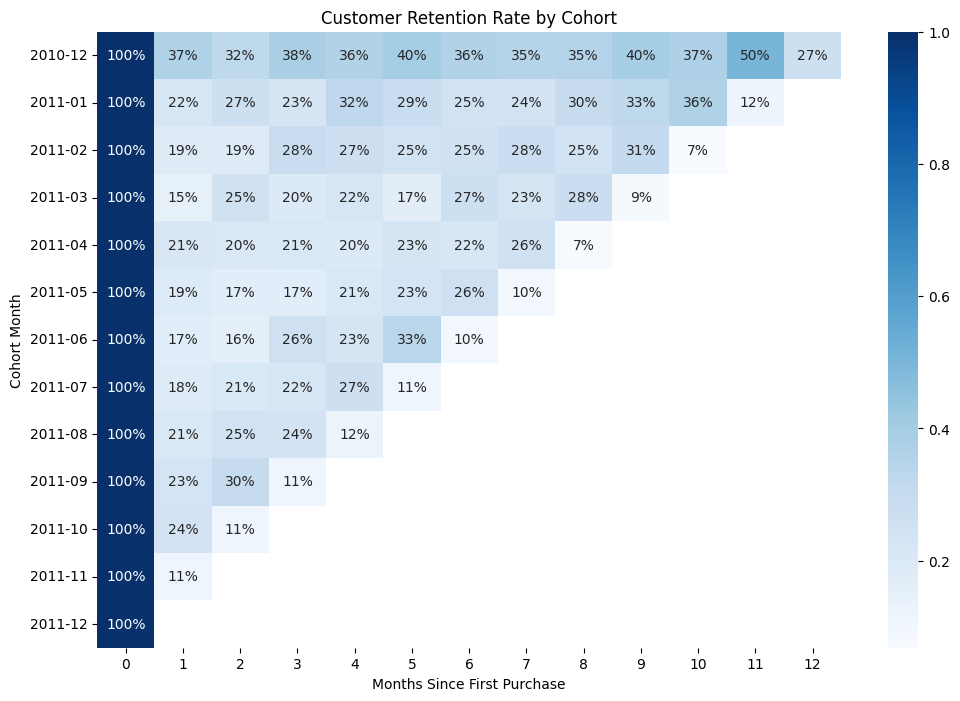

In [70]:
# Create heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues")

plt.title("Customer Retention Rate by Cohort")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.show()

### Observation

The cohort analysis reveals a clear pattern of customer retention decay over time, with the most significant drop occurring after the first month. Across nearly all cohorts, retention falls sharply from 100% in month 0 to approximately 15%-30% in month 1, indicating that a large proportion of customers do not return after their initial purchase.

After this initial decline, retention stabilizes at lower levels, generally fluctuating between 20% and 40% for several cohorts. This suggests the presence of a core group of repeat customers who contine to engage with the business over time.

Notably, earlier cohorts (e.g., December 2010 and January 2011) exhibit relatively stronger long-term retention, with some periods even showing temporary increases. This may indicate the impact of seasonal factors, customer loyalty programs, or stronger initial customer quality.

In contrast, later cohorts display more limited retention data due to the shorter observation window, rather than poorer performance.

Overall, the analysis highlights a critical opportunity to improve early-stage retention, particularly within the first month, as this is where the most substantial customer loss occurs.

## Summary

This Project provides a comprehensive analysis of an e-commerce retail dataset, focusing on sales performance, customer behavior, and retention patterns.

The analysis began with an exploration of monthly sales trends, which revealed an overall upward trajectory with notable fluctuations. A moving average was applied to smooth short-term volatility and highlight the underlying growth pattern, particularly the strong performance in the later months of the year.

Growth rate analysis further confirmed the presence of irregular but occationally significant sales spikes, suggesting that revenue is influenced by seasonal demand or promotional events rather than consistent organic growth.

Customer segmentation using RFM (Recency, Frequency, Monetary) analysis identified a highly uneven distribution of customer value. A small group of high-value customers contributes disproportionately to total revenue, while a large protion of customers show signs of low engagement or potential chrun.

Cohort analysis provided deeper insight into customer retention behavior. The results indicate a sharp decline in retention after the first purchase, with most customers failing to return beyond the initial month. However, a smaller group of repeat customers demonstrates stable long-term engagement, forming the core customer base.

Overall, the findings suggest that while the business benefits from strong peak sales periods and valuable loyal customers, improving early-stage retention and stablilizing growth patterns should be key strategic priorities.